# 04 — Boundaries and location map

Downloads the Punjab state and district polygons (geoBoundaries gbOpen IND,
CC BY 4.0), saves them to `data/boundaries/`, and draws
`results/fig_location.png` (report Figure 1). The two Ludhiana polygons used by
the pipeline are already in that folder; this notebook only reads them.

Internal boundaries only. A published map showing India's external border must
follow the Survey of India depiction, which geoBoundaries does not guarantee, so
no national outline is drawn.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import box
from shapely.ops import unary_union

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config as C

B = C.BOUNDARIES
GB = "https://media.githubusercontent.com/media/wmgeolab/geoBoundaries/main/releaseData/gbOpen/IND"
SRC = "geoBoundaries gbOpen IND (CC BY 4.0), https://www.geoboundaries.org"

In [2]:
state_f, dist_f = B / "punjab_state_geoboundaries_adm1.geojson", B / "punjab_districts_geoboundaries_adm2.geojson"
if not (state_f.exists() and dist_f.exists()):
    adm1 = gpd.read_file(f"{GB}/ADM1/geoBoundaries-IND-ADM1_simplified.geojson")
    adm2 = gpd.read_file(f"{GB}/ADM2/geoBoundaries-IND-ADM2_simplified.geojson")
    state = adm1[adm1.shapeName == "Punjab"][["shapeName", "geometry"]].copy()
    dists = adm2[adm2.representative_point().within(state.geometry.iloc[0])][["shapeName", "geometry"]].copy()
    for g, f in [(state, state_f), (dists, dist_f)]:
        g["source"] = SRC
        g["geometry"] = g.geometry.simplify(0.001, preserve_topology=True)
        g.to_file(f, driver="GeoJSON", COORDINATE_PRECISION=5)
state, dists = gpd.read_file(state_f), gpd.read_file(dist_f)
gb = gpd.read_file(B / f"{C.BOUNDARY_DEFAULT}.geojson")
dm = gpd.read_file(B / f"{C.BOUNDARY_CHECK}.geojson")
print(f"{len(dists)} Punjab districts (geoBoundaries predates Malerkotla, created 2021)")

22 Punjab districts (geoBoundaries predates Malerkotla, created 2021)


In [3]:
rc = C.grid_rowcol(pd.read_csv(C.RAW / "BGD_for_all_grids(GEOM).csv", usecols=["WKT"]).WKT)
s = C.GRID_STEP_DEG
cells = unary_union([box(c * s, r * s, (c + 1) * s, (r + 1) * s) for r, c in zip(rc.grid_row, rc.grid_col)])
cover = {n: g.geometry.iloc[0].intersection(cells).area / g.geometry.iloc[0].area for n, g in [("gb", gb), ("dm", dm)]}
print({k: round(v, 4) for k, v in cover.items()})

{'gb': 0.9304, 'dm': 0.9622}


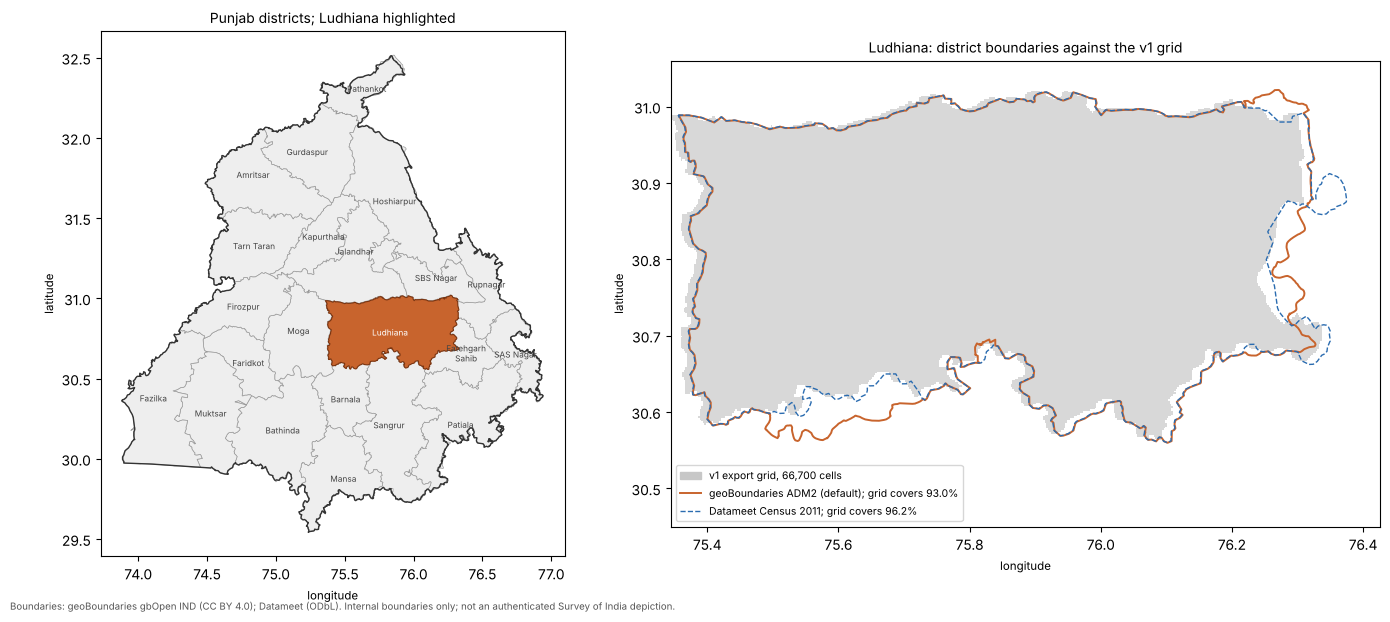

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw={"width_ratios": [1, 1.35]})
a = ax[0]
dists.plot(ax=a, color="#eeeeee", edgecolor="#9a9a9a", lw=.5)
state.boundary.plot(ax=a, color="#333", lw=1)
dists[dists.shapeName == "Ludhiana"].plot(ax=a, color="#c8642d", edgecolor="#7a3410", lw=.8)
short = {"Sahibzada Ajit Singh Nagar": "SAS Nagar", "Shahid Bhagat Singh Nagar": "SBS Nagar", "Fatehgarh Sahib": "Fatehgarh\nSahib"}
for _, r in dists.iterrows():
    p = r.geometry.representative_point()
    a.text(p.x, p.y, short.get(r.shapeName, r.shapeName), fontsize=6, ha="center", va="center",
           color="#fff" if r.shapeName == "Ludhiana" else "#444")
a.set_title("Punjab districts; Ludhiana highlighted", fontsize=10)
a.set_aspect(1 / np.cos(np.radians(30.9))); a.set_xlabel("longitude"); a.set_ylabel("latitude")

a = ax[1]
r0, c0 = rc.grid_row.min(), rc.grid_col.min()
img = np.zeros((rc.grid_row.max() - r0 + 1, rc.grid_col.max() - c0 + 1))
img[rc.grid_row - r0, rc.grid_col - c0] = 1
a.imshow(np.ma.masked_equal(img, 0), origin="lower", cmap="Greys", vmin=0, vmax=4, interpolation="nearest",
         extent=[c0 * s, (c0 + img.shape[1]) * s, r0 * s, (r0 + img.shape[0]) * s])
gb.boundary.plot(ax=a, color="#c8642d", lw=1.4)
dm.boundary.plot(ax=a, color="#2b6cb0", lw=1, ls="--")
a.legend(handles=[
    Patch(color="#c7c7c7", label="v1 export grid, 66,700 cells"),
    Line2D([], [], color="#c8642d", lw=1.4, label=f"geoBoundaries ADM2 (default); grid covers {cover['gb']:.1%}"),
    Line2D([], [], color="#2b6cb0", lw=1, ls="--", label=f"Datameet Census 2011; grid covers {cover['dm']:.1%}")],
    loc="lower left", fontsize=7.5)
a.set_title("Ludhiana: district boundaries against the v1 grid", fontsize=10)
a.set_aspect(1 / np.cos(np.radians(30.8))); a.set_xlabel("longitude"); a.set_ylabel("latitude"); a.set_ylim(30.45, 31.06)
fig.text(.01, .01, "Boundaries: geoBoundaries gbOpen IND (CC BY 4.0); Datameet (ODbL). Internal boundaries only; "
         "not an authenticated Survey of India depiction.", fontsize=7, color="#555")
plt.tight_layout(); plt.savefig(C.RESULTS / "fig_location.png", dpi=140); plt.show()